# 🧬 Algorithme Génétique — Planification des Examens
## Exam Timetabling with Genetic Algorithms

---

## 🧠 What is a Genetic Algorithm?

A **Genetic Algorithm (GA)** is inspired by **Darwinian evolution**. Instead of searching for the best timetable by brute force (which would be impossible for large datasets), we let a *population* of candidate timetables **evolve** over many **generations**.

The main loop mimics nature:

```
1. 🌱 Create a random population of timetables
2. 🔄 Repeat for N generations:
     a. 📊 Evaluate each timetable (fitness = number of conflicts)
     b. 🏆 Select the best ones (tournament selection)
     c. 💑 Combine pairs of parents (crossover / recombination)
     d. 🎲 Randomly tweak some results (mutation)
     e. 👑 Keep the best ones intact (elitism)
3. ✅ Return the timetable with the fewest conflicts
```

---

## 🎯 Problem Statement

**Hard constraint (must satisfy):** No student should have two exams scheduled at the same time slot.

**Soft constraint (nice to have):** Spread exams out — avoid back-to-back exam days.

---

## 📁 Files Used

| File | Content |
|------|---------|
| `sta-f-83.crs` | List of exams and how many students are in each |
| `sta-f-83.stu` | Each line = one student's list of exams (used to build conflict graph) |

---
## 📦 Section 1 — Imports & Setup

In [ ]:
import random
import time
import copy
import os
from collections import defaultdict
import matplotlib.pyplot as plt  # For plotting fitness over generations

# Set random seed for reproducibility (optional — remove for true randomness)
random.seed(42)

print("✅ Imports done!")

✅ Imports done!


---
## 📂 Section 2 — Loading the Dataset

### `.crs` file — The Exams
Each line: `exam_id  student_count`  
Example: `0001 13` → Exam 0001 has 13 students enrolled.

### `.stu` file — The Students → Conflict Graph
Each line lists all exams a **single student** is taking.  
Example: `0003 0013 0034` → This student takes exams 0003, 0013, and 0034.  
→ Those 3 exams **cannot** be scheduled in the same slot!

In [ ]:
def load_crs(filepath):
    """
    Load .crs file → returns list of exam IDs and their student counts.

    Returns:
        exams (list): Ordered list of exam IDs
        exam_students (dict): { exam_id -> student_count }
    """
    exams = []
    exam_students = {}

    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            exam_id = parts[0]
            count   = int(parts[1])
            exams.append(exam_id)
            exam_students[exam_id] = count

    print(f"✅ Loaded {len(exams)} exams from '{filepath}'")
    return exams, exam_students


def load_stu(filepath, exams):
    """
    Load .stu file → builds the CONFLICT GRAPH.

    Logic: if two exams appear on the same student's line,
    they CONFLICT → they cannot be in the same time slot.

    Returns:
        conflict_graph (dict): { exam_id -> set of conflicting exam_ids }
        conflict_pairs (set):  set of frozenset({a, b}) pairs
    """
    exam_set = set(exams)  # For O(1) membership check
    conflict_graph = defaultdict(set)
    conflict_pairs = set()

    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            student_exams = [e for e in line.split() if e in exam_set]
            # All pairs of exams from this student conflict!
            for i in range(len(student_exams)):
                for j in range(i + 1, len(student_exams)):
                    a, b = student_exams[i], student_exams[j]
                    conflict_graph[a].add(b)
                    conflict_graph[b].add(a)
                    conflict_pairs.add(frozenset({a, b}))

    print(f"✅ Conflict graph built — {len(conflict_pairs)} conflict pairs")
    return conflict_graph, conflict_pairs

In [ ]:
# ─── Configure Paths ───────────────────────────────────────────────────────
# Change DATASET to 'car-s-91' for the large Carleton benchmark
DATASET     = 'sta-f-83'           # ← SWITCH DATASET HERE
DATASET_DIR = '.'        # Relative path to datasets folder

CRS_FILE = os.path.join(DATASET_DIR, f'{DATASET}.crs')
STU_FILE = os.path.join(DATASET_DIR, f'{DATASET}.stu')

# Load!
exams, exam_students       = load_crs(CRS_FILE)
conflict_graph, conflict_pairs = load_stu(STU_FILE, exams)

print(f"\n📊 Dataset summary:")
print(f"   Total exams    : {len(exams)}")
print(f"   Conflict pairs : {len(conflict_pairs)}")

✅ Loaded 139 exams from './sta-f-83.crs'
✅ Conflict graph built — 1381 conflict pairs

📊 Dataset summary:
   Total exams    : 139
   Conflict pairs : 1381


---
## 🧬 Section 3 — Chromosome Representation

In a GA, each **individual** (candidate solution) is called a **chromosome**.

Here, one chromosome = one complete timetable:

```python
chromosome = {
    '0001': 3,   # Exam 0001 is in time slot 3
    '0002': 1,   # Exam 0002 is in time slot 1
    '0003': 3,   # Exam 0003 is in time slot 3  ← CONFLICT if 0001 & 0003 share students!
    ...
}
```

### ⚙️ Key Parameter: `NUM_SLOTS`
The number of available time slots.
- **Too few** → impossible to avoid conflicts
- **Too many** → easy but wasteful
- Rule of thumb: start with `num_exams // 5` to `num_exams // 3`

In [ ]:
# ─── PARAMETER: Number of Time Slots ──────────────────────────────────────
# Adjust this! More slots → fewer conflicts but a longer timetable.
NUM_SLOTS = 25   # ← TUNE THIS PARAMETER

def create_individual(exams, num_slots):
    """
    Create ONE random timetable.
    Each exam gets a random slot from 0 to num_slots-1.
    """
    return {exam: random.randint(0, num_slots - 1) for exam in exams}


def create_population(exams, num_slots, pop_size):
    """
    Create the initial population of 'pop_size' random timetables.

    ⚙️ Parameter: pop_size
    ─────────────────────
    Larger population = more genetic diversity = harder to get stuck in local optima.
    But each generation takes longer to evaluate.
    Typical: 50-300. We use 100 by default.
    """
    return [create_individual(exams, num_slots) for _ in range(pop_size)]


# Demo: create and show one individual
sample = create_individual(exams, NUM_SLOTS)
print("🧬 Sample chromosome (first 5 exams):")
for exam in exams[:5]:
    print(f"   Exam {exam} → Slot {sample[exam]}")

🧬 Sample chromosome (first 5 exams):
   Exam 0001 → Slot 20
   Exam 0002 → Slot 3
   Exam 0003 → Slot 0
   Exam 0004 → Slot 23
   Exam 0005 → Slot 8


---
## 📊 Section 4 — Fitness Function

The **fitness function** measures how good a timetable is.

We count the number of **conflicts**:
- For every pair of exams that conflict (share at least one student),
- If they're in the **same slot** → +1 conflict penalty.

**Goal: minimize conflicts → ideally reach 0.**

In [ ]:
def count_conflicts(individual, conflict_pairs):
    """
    Count how many conflicting exam pairs are scheduled in the same slot.

    This is the FITNESS SCORE — lower = better.
    0 conflicts = PERFECT timetable ✅

    Args:
        individual (dict): { exam_id -> slot_number }
        conflict_pairs (set): set of frozenset({exam_a, exam_b})

    Returns:
        int: number of conflicts (0 = perfect)
    """
    conflicts = 0
    for pair in conflict_pairs:
        pair_list = list(pair)
        if len(pair_list) == 2:
            a, b = pair_list
            # If both exams are in the same slot → conflict!
            if individual.get(a) == individual.get(b):
                conflicts += 1
    return conflicts


# Demo: evaluate our sample individual
sample_conflicts = count_conflicts(sample, conflict_pairs)
print(f"🔍 Sample individual has {sample_conflicts} conflicts (random, so likely many)")

🔍 Sample individual has 54 conflicts (random, so likely many)


---
## 🏆 Section 5 — Selection (Tournament Selection)

We need to choose **which individuals reproduce** — better ones should have a higher chance.

**Tournament Selection:**
1. Randomly pick `k` individuals from the population.
2. Return the one with the **lowest** conflict count.

### ⚙️ Parameter: `tournament_size` (k)
| k | Effect |
|---|--------|
| 2 | Weak selection — preserves diversity, slow convergence |
| 3 | Balanced (recommended default) |
| 5+ | Strong selection — fast convergence, risk of getting stuck |

In [ ]:
def tournament_selection(population, fitnesses, tournament_size=3):
    """
    Select one individual using Tournament Selection.

    Process:
      1. Randomly pick 'tournament_size' individuals from the population
      2. Return the one with the lowest fitness (fewest conflicts)

    ⚙️ Parameter: tournament_size
       Higher = more selection pressure (best wins more often)
       Lower  = more diversity (weaker individuals survive sometimes)
    """
    candidates_idx = random.sample(range(len(population)), tournament_size)
    best_idx = min(candidates_idx, key=lambda i: fitnesses[i])
    return population[best_idx]

---
## 💑 Section 6 — Crossover (Recombination)

Crossover combines two parent timetables to create a child that (hopefully) inherits the best of both.

**Uniform Crossover:**
For each exam, the child randomly inherits the slot from **Parent 1** OR **Parent 2** (50/50 coin flip).

```
Parent 1: { A→3, B→1, C→5, D→2 }
Parent 2: { A→7, B→1, C→3, D→4 }
Child:    { A→3, B→1, C→3, D→4 }  ← mixed!
             P1   P1   P2   P2
```

### ⚙️ Parameter: `crossover_rate`
- Probability that crossover actually happens (vs just cloning parent 1).
- Typical range: **0.8–0.95**.

In [ ]:
def crossover(parent1, parent2, crossover_rate=0.85):
    """
    Uniform crossover between two parents.

    For each exam:
      - 50% chance: inherit slot from parent1
      - 50% chance: inherit slot from parent2

    If random() > crossover_rate → skip crossover, clone parent1 instead.

    ⚙️ Parameter: crossover_rate
       High (0.9) → lots of mixing → more exploration
       Low  (0.5) → less mixing  → stays closer to parents
    """
    if random.random() > crossover_rate:
        return copy.copy(parent1)  # No crossover — just clone

    child = {}
    for exam in parent1:
        # Each gene (exam slot) inherited from either parent with equal probability
        child[exam] = parent1[exam] if random.random() < 0.5 else parent2[exam]
    return child


# Demo crossover
pop_demo = create_population(exams, NUM_SLOTS, 10)
p1, p2   = pop_demo[0], pop_demo[1]
child    = crossover(p1, p2)
print("👨 Parent 1 (first 3 exams):", {e: p1[e] for e in exams[:3]})
print("👩 Parent 2 (first 3 exams):", {e: p2[e] for e in exams[:3]})
print("👶 Child    (first 3 exams):", {e: child[e] for e in exams[:3]})

👨 Parent 1 (first 3 exams): {'0001': 18, '0002': 12, '0003': 11}
👩 Parent 2 (first 3 exams): {'0001': 18, '0002': 15, '0003': 7}
👶 Child    (first 3 exams): {'0001': 18, '0002': 12, '0003': 11}


---
## 🎲 Section 7 — Mutation

Mutation prevents the algorithm from getting **stuck in a local optimum** — a solution that seems good but isn't globally optimal.

We use **two mutation strategies**:

### 1. Random Mutation
Reassign an exam to a completely random slot.

### 2. Smart (Conflict-Directed) Mutation 🧠
If an exam is currently conflicting with neighbors:
- Try a handful of slots
- Pick the one that creates **the fewest new conflicts**

This is a local search step embedded in the GA — making it a **memetic algorithm**.

### ⚙️ Parameter: `mutation_rate`
| Rate | Effect |
|------|--------|
| 0.01 | Very low — algorithm converges fast but may get stuck |
| 0.05 | Balanced default |
| 0.1+ | High — lots of random jumps, slower convergence but escapes local optima |

In [ ]:
def mutate(individual, conflict_graph, num_slots, mutation_rate=0.05):
    """
    Apply mutation to an individual timetable.

    For each exam (with probability = mutation_rate):
      → If the exam is currently conflicting:
           SMART MUTATION: try 10 random slots, keep the best one
      → Otherwise:
           RANDOM MUTATION: assign a completely random slot

    Modifies 'individual' IN PLACE and returns it.

    ⚙️ Parameter: mutation_rate
       Per-exam probability of mutation.
       Too low → gets stuck; Too high → too random = no learning.
    """
    for exam in individual:
        if random.random() < mutation_rate:
            neighbors = conflict_graph.get(exam, set())

            # Check if this exam is currently conflicting
            conflicting = [
                n for n in neighbors
                if individual.get(n) == individual[exam]
            ]

            if conflicting:
                # ── Smart Mutation ──────────────────────────────────────
                # Find the slot (among a random sample) that causes the
                # fewest conflicts for this exam.
                best_slot           = individual[exam]
                best_conflict_count = len(conflicting)

                sample_slots = random.sample(range(num_slots), min(10, num_slots))
                for slot in sample_slots:
                    conflicts_in_slot = sum(
                        1 for n in neighbors if individual.get(n) == slot
                    )
                    if conflicts_in_slot < best_conflict_count:
                        best_conflict_count = conflicts_in_slot
                        best_slot = slot

                individual[exam] = best_slot
            else:
                # ── Random Mutation ─────────────────────────────────────
                individual[exam] = random.randint(0, num_slots - 1)

    return individual

---
## 🔄 Section 8 — Main Genetic Algorithm Loop

### Big Picture Flow

```
Population(0)  →  Evaluate  →  Select  →  Crossover  →  Mutate  →  Population(1)
                     ↑                                                    ↓
                 Fitness                                              [Repeat]
```

### ⚙️ All Parameters Summary

| Parameter | What it does | Recommended |
|-----------|--------------|-------------|
| `num_slots` | Available time slots | 25–35 (tune per dataset) |
| `pop_size` | Individuals per generation | 100–200 |
| `num_generations` | How long to evolve | 300–1000 |
| `crossover_rate` | Probability of crossover | 0.85 |
| `mutation_rate` | Per-exam mutation chance | 0.05 |
| `tournament_size` | Selection pressure | 3 |
| `elite_size` | Best individuals preserved | 5 |
| `time_limit` | Max runtime (seconds) | 300 |

In [ ]:
def genetic_algorithm(
    exams,
    conflict_graph,
    conflict_pairs,
    num_slots=25,
    pop_size=100,
    num_generations=500,
    crossover_rate=0.85,
    mutation_rate=0.05,
    tournament_size=3,
    elite_size=5,
    time_limit=300
):
    """
    Full Genetic Algorithm for Exam Timetabling.

    Returns:
        best_individual (dict): best timetable {exam_id -> slot}
        best_fitness    (int):  conflicts in best timetable
        total_time      (float): wall-clock time in seconds
        history         (list): best fitness per generation (for plotting)
    """
    start_time = time.time()
    history    = []  # Track best fitness per generation

    # ────────────────────────────────────────────────
    # STEP 1: Create initial random population
    # ────────────────────────────────────────────────
    print(f"🌱 Creating initial population ({pop_size} individuals, {num_slots} slots)...")
    population   = create_population(exams, num_slots, pop_size)
    best_individual = None
    best_fitness    = float('inf')

    # ────────────────────────────────────────────────
    # STEP 2: Evolution loop
    # ────────────────────────────────────────────────
    for generation in range(num_generations):

        # Safety stop
        elapsed = time.time() - start_time
        if elapsed > time_limit:
            print(f"⏱️ Time limit ({time_limit}s) reached at generation {generation}.")
            break

        # ── 2a. Evaluate fitness for ALL individuals ──
        fitnesses = [count_conflicts(ind, conflict_pairs) for ind in population]

        # ── 2b. Track global best ──
        gen_best_idx     = min(range(len(fitnesses)), key=lambda i: fitnesses[i])
        gen_best_fitness = fitnesses[gen_best_idx]
        history.append(gen_best_fitness)

        if gen_best_fitness < best_fitness:
            best_fitness    = gen_best_fitness
            best_individual = copy.deepcopy(population[gen_best_idx])

        # Print progress
        if generation % 50 == 0 or best_fitness == 0:
            print(f"  Generation {generation:4d} | Best conflicts: {best_fitness:5d} | Time: {elapsed:.1f}s")

        # ── 2c. Stop if perfect ──
        if best_fitness == 0:
            print(f"\n✅ Perfect solution found at generation {generation}!")
            break

        # ── 2d. Build next generation ──
        new_population = []

        # ELITISM: preserve the top 'elite_size' individuals unchanged
        # This ensures we never lose our best solution!
        sorted_indices = sorted(range(len(fitnesses)), key=lambda i: fitnesses[i])
        for i in range(elite_size):
            new_population.append(copy.deepcopy(population[sorted_indices[i]]))

        # REPRODUCTION: fill rest with children from crossover + mutation
        while len(new_population) < pop_size:
            parent1 = tournament_selection(population, fitnesses, tournament_size)
            parent2 = tournament_selection(population, fitnesses, tournament_size)
            child   = crossover(parent1, parent2, crossover_rate)
            child   = mutate(child, conflict_graph, num_slots, mutation_rate)
            new_population.append(child)

        population = new_population

    total_time = time.time() - start_time
    print(f"\n⏱️ Total time: {total_time:.2f}s | Final conflicts: {best_fitness}")
    return best_individual, best_fitness, total_time, history

---
## 🚀 Section 9 — Run the Algorithm!

In [ ]:
print("=" * 55)
print("  🧬 GENETIC ALGORITHM — EXAM TIMETABLING")
print(f"  Dataset: {DATASET}")
print("=" * 55)

# ⚙️ TUNE PARAMETERS HERE:
best_individual, best_fitness, total_time, history = genetic_algorithm(
    exams           = exams,
    conflict_graph  = conflict_graph,
    conflict_pairs  = conflict_pairs,
    num_slots       = 25,    # ← Time slots (tune per dataset)
    pop_size        = 100,   # ← Population size
    num_generations = 500,   # ← Max generations
    crossover_rate  = 0.85,  # ← Crossover probability
    mutation_rate   = 0.05,  # ← Per-exam mutation probability
    tournament_size = 3,     # ← Selection pressure
    elite_size      = 5,     # ← Elites preserved per generation
    time_limit      = 300    # ← Max seconds
)

  🧬 GENETIC ALGORITHM — EXAM TIMETABLING
  Dataset: sta-f-83
🌱 Creating initial population (100 individuals, 25 slots)...
  Generation    0 | Best conflicts:    38 | Time: 0.0s
  Generation   50 | Best conflicts:     4 | Time: 4.3s
  Generation  100 | Best conflicts:     3 | Time: 7.5s
  Generation  150 | Best conflicts:     2 | Time: 10.6s
  Generation  200 | Best conflicts:     1 | Time: 13.6s
  Generation  250 | Best conflicts:     1 | Time: 17.8s
  Generation  282 | Best conflicts:     0 | Time: 19.7s

✅ Perfect solution found at generation 282!

⏱️ Total time: 19.76s | Final conflicts: 0


---
## 📈 Section 10 — Visualize Convergence

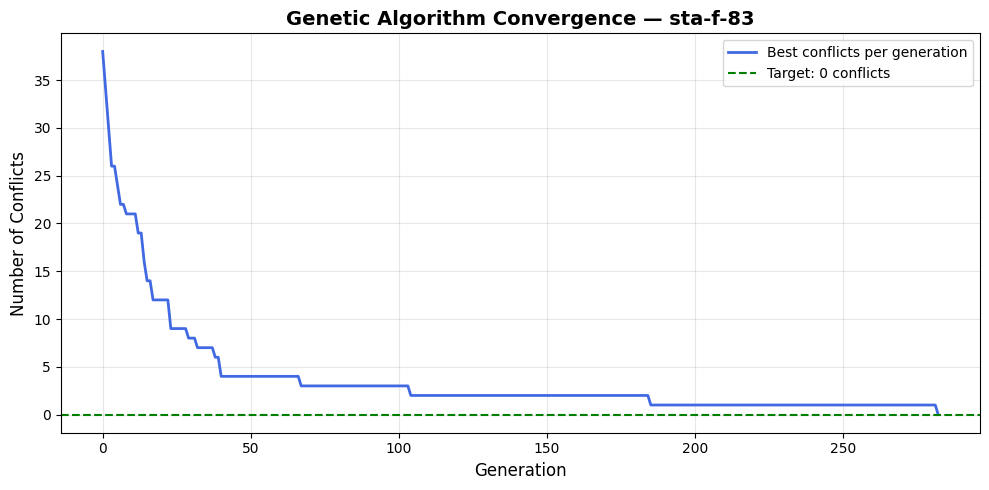

📊 Convergence plot saved as 'ga_convergence.png'


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history, color='royalblue', linewidth=2, label='Best conflicts per generation')
plt.axhline(y=0, color='green', linestyle='--', linewidth=1.5, label='Target: 0 conflicts')
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Number of Conflicts', fontsize=12)
plt.title(f'Genetic Algorithm Convergence — {DATASET}', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ga_convergence.png', dpi=150)
plt.show()
print("📊 Convergence plot saved as 'ga_convergence.png'")

---
## 📅 Section 11 — Display Final Timetable

In [ ]:
def display_timetable(individual, num_slots):
    """Print the timetable grouped by slot."""
    slot_map = defaultdict(list)
    for exam, slot in individual.items():
        slot_map[slot].append(exam)

    print("\n📅 FINAL TIMETABLE:")
    print("─" * 45)
    for slot in range(num_slots):
        if slot_map[slot]:
            exams_in_slot = ', '.join(sorted(slot_map[slot]))
            print(f"  Slot {slot:2d} ({len(slot_map[slot]):3d} exams): {exams_in_slot}")
    print("─" * 45)
    print(f"  Slots used: {len(slot_map)} / 25")

display_timetable(best_individual, num_slots=25)


📅 FINAL TIMETABLE:
─────────────────────────────────────────────
  Slot  0 (  6 exams): 0015, 0055, 0059, 0079, 0081, 0120
  Slot  1 (  4 exams): 0005, 0029, 0097, 0133
  Slot  2 (  6 exams): 0024, 0061, 0080, 0112, 0131, 0137
  Slot  3 (  4 exams): 0032, 0072, 0074, 0076
  Slot  4 (  7 exams): 0016, 0020, 0039, 0042, 0045, 0091, 0095
  Slot  5 (  5 exams): 0019, 0038, 0046, 0052, 0115
  Slot  6 (  7 exams): 0043, 0062, 0092, 0096, 0100, 0121, 0135
  Slot  7 (  8 exams): 0008, 0040, 0041, 0056, 0065, 0066, 0078, 0126
  Slot  8 (  3 exams): 0049, 0071, 0136
  Slot  9 (  4 exams): 0017, 0044, 0099, 0104
  Slot 10 (  6 exams): 0001, 0002, 0027, 0028, 0105, 0106
  Slot 11 (  6 exams): 0014, 0031, 0036, 0109, 0111, 0129
  Slot 12 (  6 exams): 0013, 0053, 0087, 0090, 0123, 0134
  Slot 13 (  4 exams): 0006, 0012, 0021, 0026
  Slot 14 (  3 exams): 0004, 0030, 0037
  Slot 15 (  5 exams): 0009, 0034, 0067, 0068, 0114
  Slot 16 (  6 exams): 0025, 0048, 0077, 0117, 0119, 0130
  Slot 17 (  8 exams

---
## 🏁 Section 12 — Final Required Output

In [ ]:
# ⚠️ Required output format — do NOT change!
print(f"[RESULT] Algorithm: Genetic Algorithm | Time: {total_time:.1f}s | Conflicts: {best_fitness}")

[RESULT] Algorithm: Genetic Algorithm | Time: 19.8s | Conflicts: 0


---
## 🔧 Section 13 — Tuning Tips

If your algorithm doesn't find a conflict-free solution, try these adjustments:

| Problem | Fix |
|---------|-----|
| Conflicts never reach 0 | Increase `num_slots` (e.g. 30→35) |
| Converges too fast (gets stuck) | Increase `mutation_rate` (0.05→0.1) |
| Converges too slowly | Increase `pop_size` or `tournament_size` |
| Running too slow | Decrease `pop_size` or use `time_limit` |
| Large dataset (car-s-91) | Use `pop_size=200`, `num_generations=1000`, `time_limit=600` |

---

## 📚 Summary of GA Concepts

| Biological Term | GA Term | Our Implementation |
|-----------------|---------|--------------------|
| Organism | Individual / Chromosome | Dict: {exam → slot} |
| DNA | Genes | Slot assignments |
| Population | Group of solutions | List of dicts |
| Fitness | How good a solution is | Number of conflicts |
| Natural selection | Tournament selection | Pick best from k random |
| Reproduction | Crossover | Uniform mixing of two parents |
| DNA mutation | Mutation | Random or smart slot change |
| Elite breeding | Elitism | Keep top N unchanged |